# Principle-wise model aligment comparison


In [1]:
from pathlib import Path
import re
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
DATA_DIR = Path('eval')  

def parse_eval_filename(path: Path) -> dict:
    stem = path.stem
    raw_name = stem

    if stem.startswith("eval_icai_tuned"):
        model_constitution = "ICAI"
        body = stem[len("eval_"):]  
    elif stem.startswith("eval_tuned"):
        model_constitution = "OURS"
        body = stem[len("eval_"):]    
    else:
        model_constitution = "NONE"
        body = stem[len("eval_"):] 

    if "_judged_" in body:
        before, after = body.split("_judged_", 1)
        judge_token = after.split("_", 1)[0]  # 'ours' or 'icai'
        judge_constitution = "ICAI" if judge_token.lower() == "icai" else "OURS"
    elif body.startswith("icai"):
        judge_constitution = "ICAI"
        before = body
    else:
        judge_constitution = "OURS"
        before = body


    model_clean = before

    m_temp = re.search(r"([0-9.]+)", model_clean)
    if m_temp:
        temp = float(m_temp.group(1))
    else:
        temp = 0.0

    result = {
        "raw_name": raw_name,
        "model_clean": model_clean,
        "model_constitution": model_constitution,
        "judge_constitution": judge_constitution,
        "temp": temp,
    }

    print(result)
    return result

In [ ]:
rubric_pattern = re.compile(r"\[(.*?)\]")

def load_eval_file(path: Path) -> pd.DataFrame:
    if "mistral_base" in str(path):
        meta = parse_eval_filename(path)
    
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)
    
        if not isinstance(data, list) or len(data) == 0:
            raise ValueError(f"Unexpected JSON structure in {path}")
    
        summary_scores = data[0]
    
        if not isinstance(summary_scores, (list, tuple)):
            raise ValueError(f"First entry in {path} is not a list of scores")
    
        principle_names = None
        for entry in data[1:]:
            if isinstance(entry, list) and len(entry) == 2 and isinstance(entry[1], str):
                names = [m.group(1) for m in rubric_pattern.finditer(entry[1])]
                if names:
                    principle_names = names
                    break
    
        if principle_names is None or len(principle_names) != len(summary_scores):
            principle_names = [f"Principle {i+1}" for i in range(len(summary_scores))]
    
        rows = []
        for i, score in enumerate(summary_scores):
            rows.append(
                {
                    "file": meta["raw_name"],
                    "model_clean": meta["model_clean"],
                    "model_constitution": meta["model_constitution"],
                    "judge_constitution": meta["judge_constitution"],
                    "temp": meta["temp"],
                    "principle": principle_names[i],
                    "score": float(score),
                }
            )
    
        return pd.DataFrame(rows)

In [4]:
if not DATA_DIR.exists():
    print("WARNING: DATA_DIR does not exist:", DATA_DIR)

files = sorted(
    p for p in DATA_DIR.glob("eval*.json")
    if not p.stem.startswith("eval_combined")
)

print(f"Found {len(files)} eval JSON files in {DATA_DIR}")

dfs = []
for p in files:
    try:
        df_p = load_eval_file(p)
        dfs.append(df_p)
    except Exception as e:
        print(f"Error loading {p.name}: {e}")

if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
else:
    df_all = pd.DataFrame(columns=[
        "file",
        "model_clean",
        "model_constitution",
        "judge_constitution",
        "temp",
        "principle",
        "score",
    ])

print("df_all shape:", df_all.shape)
df_all.head()

Found 28 eval JSON files in eval
{'raw_name': 'eval_base_sft_mistral_base_0.5', 'model_clean': 'base_sft_mistral_base_0.5', 'model_constitution': 'NONE', 'judge_constitution': 'OURS', 'temp': 0.5}
{'raw_name': 'eval_base_sft_mistral_base_1', 'model_clean': 'base_sft_mistral_base_1', 'model_constitution': 'NONE', 'judge_constitution': 'OURS', 'temp': 1.0}
{'raw_name': 'eval_base_sft_mistral_base_greedy', 'model_clean': 'base_sft_mistral_base_greedy', 'model_constitution': 'NONE', 'judge_constitution': 'OURS', 'temp': 0.0}
{'raw_name': 'eval_base_sft_mistral_base_judged_icai_greedy', 'model_clean': 'base_sft_mistral_base', 'model_constitution': 'NONE', 'judge_constitution': 'ICAI', 'temp': 0.0}
{'raw_name': 'eval_icai_base_sft_mistral_base_0.5', 'model_clean': 'icai_base_sft_mistral_base_0.5', 'model_constitution': 'NONE', 'judge_constitution': 'ICAI', 'temp': 0.5}
{'raw_name': 'eval_icai_base_sft_mistral_base_1', 'model_clean': 'icai_base_sft_mistral_base_1', 'model_constitution': 'NONE

,file,model_clean,model_constitution,judge_constitution,temp,principle,score
0,eval_base_sft_mistral_base_0.5,base_sft_mistral_base_0.5,NONE,OURS,0.5,Authentic Voice Alignment,1.82
1,eval_base_sft_mistral_base_0.5,base_sft_mistral_base_0.5,NONE,OURS,0.5,Direct and Thoughtful Response,1.66
2,eval_base_sft_mistral_base_0.5,base_sft_mistral_base_0.5,NONE,OURS,0.5,Precision and Accuracy,1.43
3,eval_base_sft_mistral_base_0.5,base_sft_mistral_base_0.5,NONE,OURS,0.5,Explain Causes and Risks,1.43
4,eval_base_sft_mistral_base_0.5,base_sft_mistral_base_0.5,NONE,OURS,0.5,Comprehensive Helpfulness,1.39


In [5]:
temps = sorted(df_all["temp"].unique())

for t in temps:
    sub = df_all[(df_all["temp"] == t) &
                  (df_all["model_clean"].isin(["base_mistral", "tuned_sft_mistral"]))]

    if sub.empty:
        continue

    pivot = sub.pivot_table(index="principle",
                            columns="model_clean",
                            values="score",
                            aggfunc="mean")

    pivot.plot(kind="bar", figsize=(12, 5))
    plt.title(f"Base model comparison @ temperature = {t}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean score")
    plt.tight_layout()
    plt.show()

In [6]:
temps = sorted(df_all["temp"].unique())

for t in temps:
    sub = df_all[(df_all["temp"] == t) &
                  (df_all["model_clean"].isin(["icai_base_mistral", "icai_tuned_sft_mistral"]))]

    if sub.empty:
        continue

    pivot = sub.pivot_table(index="principle",
                            columns="model_clean",
                            values="score",
                            aggfunc="mean")

    pivot.plot(kind="bar", figsize=(12, 5))
    plt.title(f"Base model comparison @ temperature = {t}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Mean score")
    plt.tight_layout()
    plt.show()

In [ ]:
model_colors = {
    "base_sft_mistral": "C0",
    "tuned_sft_mistral": "C1",
    "icai_base_sft_mistral": "C2",
    "icai_tuned_sft_mistral": "C3",
}

def radar_cross_by_temp_judged(temp_value, df_all, judge_constitution):
    """
    For a given temperature and judge_constitution ("OURS" or "ICAI"),
    plot separate curves for each model_clean that was JUDGED by that constitution.

    - Only Mistral models are shown.
    - All DPO models are excluded.
    - Color encodes the *model* (model_clean), not the constitution.
    - Label shows which constitution the model was trained on.
    """
    sub = df_all[
        (df_all["temp"] == temp_value)
        & (df_all["judge_constitution"] == judge_constitution)
        # & (
       # (df_all["model_constitution"] == judge_constitution)
       # | (df_all["model_constitution"] == "NONE")
   # )
        & (df_all["model_clean"].str.contains("mistral", case=False, na=False))
        #  & ~df_all["model_clean"].str.contains("icai_base_sft_mistral", case=False, na=False)
    ]

    if sub.empty:
        print(f"No data for temp={temp_value}, judged by {judge_constitution}")
        return

    pivot = sub.pivot_table(
        index="principle",
        columns="model_clean",
        values="score",
        aggfunc="mean",
    ).sort_index()

    model_const_map = sub.groupby("model_clean")["model_constitution"].first().to_dict()

    principles = pivot.index.tolist()
    n_axes = len(principles)

    angles = np.linspace(0, 2 * np.pi, n_axes, endpoint=False)
    angles = np.concatenate([angles, [angles[0]]])

    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(111, polar=True)

    for model_name in pivot.columns:
        values = pivot[model_name].values
        values = np.concatenate([values, [values[0]]])

        color = model_colors.get(model_name, None)
        m_const = model_const_map.get(model_name, "OURS")
        label = f"(trained on {m_const}, judged by {judge_constitution})"

        ax.plot(angles, values, marker="o", label=label, color=color)
        ax.fill(angles, values, alpha=0.12, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(principles, fontsize=9)

    ax.set_title(
        f"Principle scores @ temp {temp_value}\n"
        f"Models judged by {judge_constitution}"
    )
    ax.set_rlabel_position(0)
    plt.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1))
    plt.tight_layout()
    plt.show()




 Temperature 0.0 — models aligned with SFT on our constitution


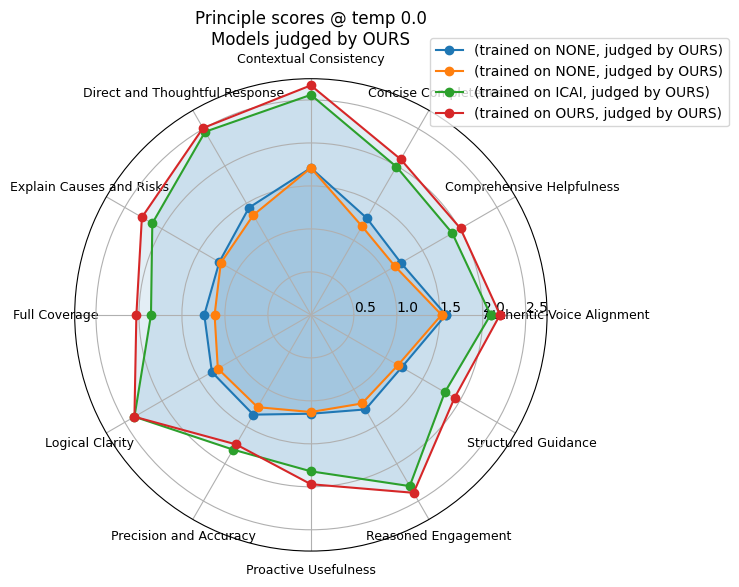


 Temperature 0.0 — models aligned with SFT on ICAI


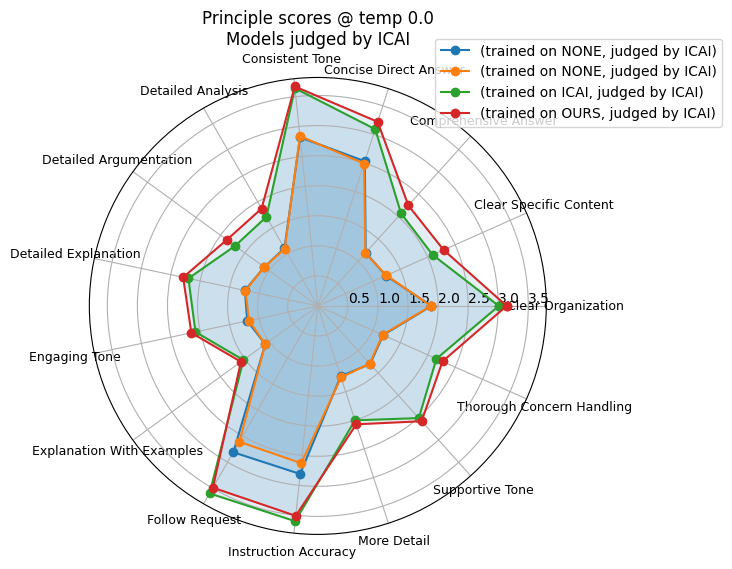


 Temperature 0.5 — models aligned with SFT on our constitution


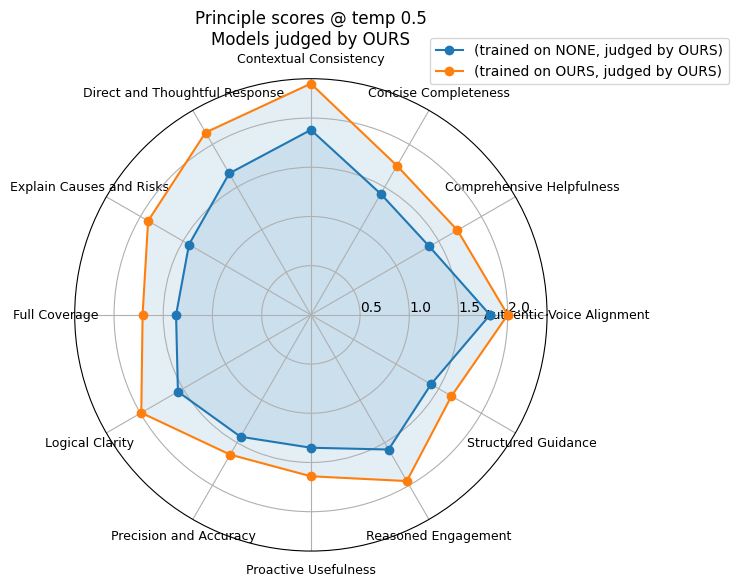


 Temperature 0.5 — models aligned with SFT on ICAI


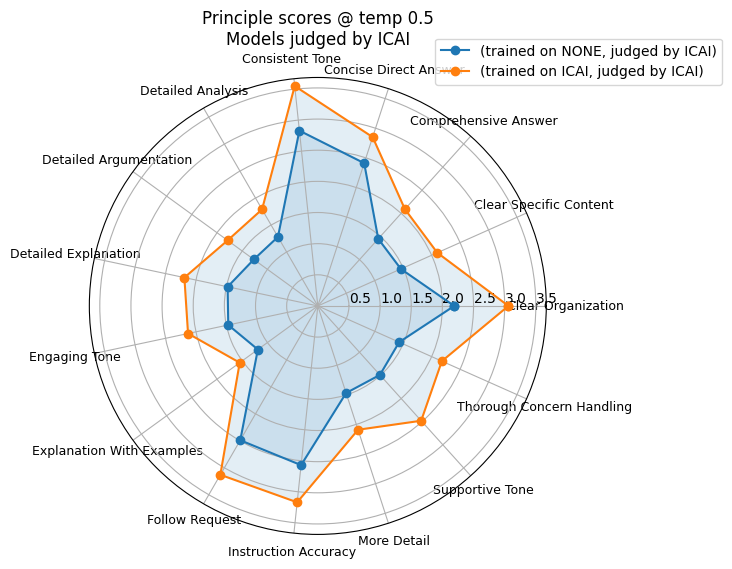


 Temperature 1.0 — models aligned with SFT on our constitution


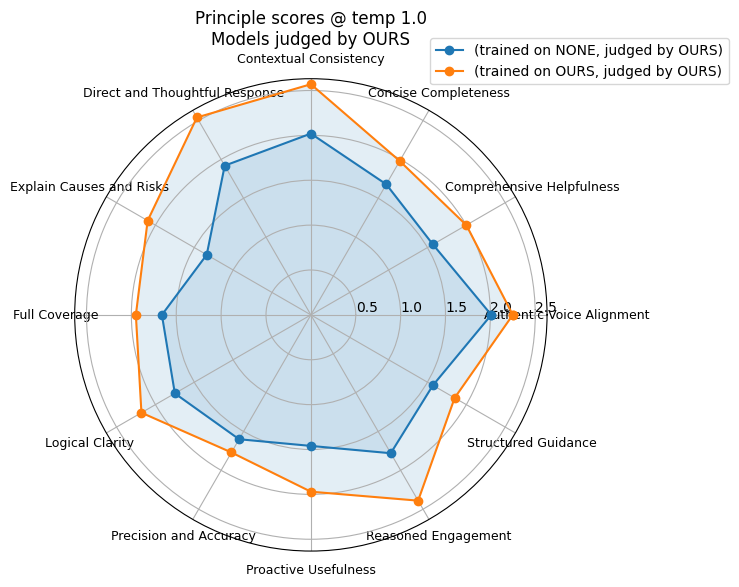


 Temperature 1.0 — models aligned with SFT on ICAI


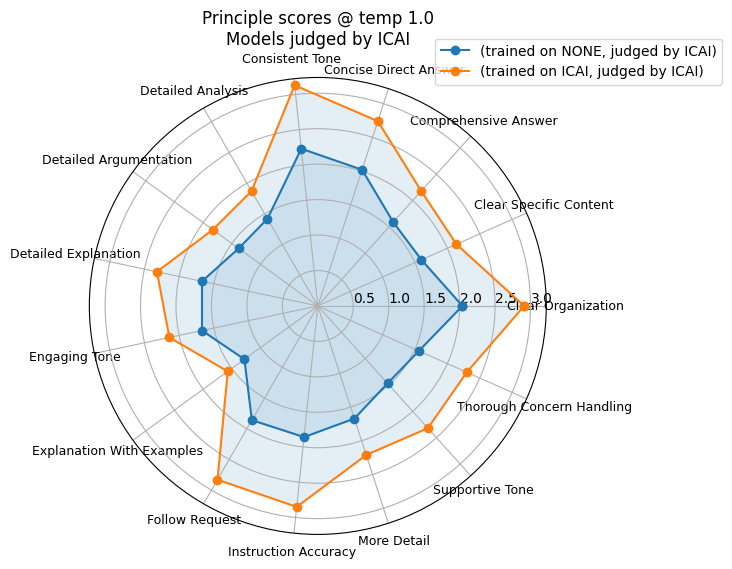

In [8]:
for t in sorted(df_all["temp"].unique()):
    print(f"\n Temperature {t} — models aligned with SFT on our constitution")
    radar_cross_by_temp_judged(t, df_all, judge_constitution="OURS")

    print(f"\n Temperature {t} — models aligned with SFT on ICAI")
    radar_cross_by_temp_judged(t, df_all, judge_constitution="ICAI")

In [ ]:
bar_colors = {
    "OURS": "C1",   # tuned_sft_mistral
    "ICAI": "C3",   # icai_tuned_sft_mistral
}


def bar_tuned_by_judge(temp_value, df_all, judge_constitution):
    """
    For a given temperature and judge_constitution ("OURS" or "ICAI"),
    create ONE bar plot that shows, for each principle:

        - tuned_sft_mistral   (trained on OURS)
        - icai_tuned_sft_mistral (trained on ICAI)

    Both evaluated under the same judge_constitution.
    """
    sub = df_all[
        (df_all["temp"] == temp_value)
        & (df_all["judge_constitution"] == judge_constitution)
        & (df_all["model_clean"].isin(["tuned_sft_mistral", "icai_tuned_sft_mistral"]))
    ]

    if sub.empty:
        print(f"No tuned-model data for temp={temp_value}, judged by {judge_constitution}")
        return

    # rows: principles, columns: training constitution (OURS/ICAI)
    pivot = sub.pivot_table(
        index="principle",
        columns="model_constitution",
        values="score",
        aggfunc="mean",
    ).sort_index()

    principles = pivot.index.tolist()
    x = np.arange(len(principles))
    width = 0.35

    ours_scores = pivot["OURS"] if "OURS" in pivot.columns else np.zeros(len(principles))
    icai_scores = pivot["ICAI"] if "ICAI" in pivot.columns else np.zeros(len(principles))

    fig, ax = plt.subplots(figsize=(10, 4))

    ax.bar(x - width/2, ours_scores, width,
           label="tuned_sft_mistral (trained on OURS)",
           color=bar_colors.get("OURS"))
    ax.bar(x + width/2, icai_scores, width,
           label="icai_tuned_sft_mistral (trained on ICAI)",
           color=bar_colors.get("ICAI"))

    ax.set_xticks(x)
    ax.set_xticklabels(principles, rotation=45, ha="right")
    ax.set_ylabel("Score")
    ax.set_title(
        f"Tuned models judged by {judge_constitution} @ temp {temp_value}"
    )
    ax.legend()
    plt.tight_layout()
    plt.show()
